# **Heart Disease Prediction using Machine Learning**

## Objective

The objective of this project is to develop a Machine Learning model that predicts whether a patient is likely to have heart disease based on various medical attributes. The project includes data preprocessing, exploratory data analysis, model training using Logistic Regression and Decision Tree, performance evaluation, and model saving for future predictions.

In [ ]:
# Import libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Data visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Model saving

import joblib

In [ ]:
# Load dataset

df = pd.read_csv("heart_disease_uci.csv")

# Display first five rows

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
# Display dataset shape

print("Dataset Shape:", df.shape)

Dataset Shape: (920, 16)


In [ ]:
# Display column names

print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [ ]:
# Display statistical summary

df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
# Check for missing values

df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [ ]:
# Check duplicate records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Display target variable distribution

print(df["num"].value_counts())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [ ]:
# Display target variable percentage

print(df["num"].value_counts(normalize=True) * 100)

num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64


In [ ]:
# Convert target into binary classification

df["target"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

# Display target distribution

print(df["target"].value_counts())

target
1    509
0    411
Name: count, dtype: int64


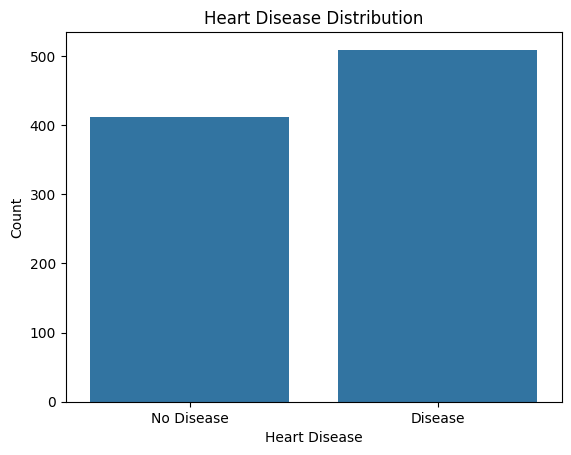

In [ ]:
# Visualize target distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.show()

In [ ]:
# Check missing values in each column

df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [ ]:
# Display missing values in descending order

missing_values = df.isnull().sum().sort_values(ascending=False)

print(missing_values)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
id            0
dataset       0
cp            0
age           0
sex           0
num           0
target        0
dtype: int64


In [ ]:
# Fill missing values

for column in df.columns:

    # Fill numerical columns with median
    if df[column].dtype in ["int64", "float64"]:
        df[column].fillna(df[column].median(), inplace=True)

    # Fill categorical columns with mode
    else:
        df[column].fillna(df[column].mode()[0], inplace=True)

In [ ]:
# Verify missing values after preprocessing

df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [ ]:
# Display data types

df.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,bool
restecg,object
thalch,float64


In [ ]:
# Perform One-Hot Encoding

df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Display first five rows after encoding

df.head()

,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,True,150.0,False,2.3,0.0,0,...,False,False,False,True,False,False,False,False,False,False
1,2,67,160.0,286.0,False,108.0,True,1.5,3.0,2,...,False,False,False,False,False,False,True,False,True,False
2,3,67,120.0,229.0,False,129.0,True,2.6,2.0,1,...,False,False,False,False,False,False,True,False,False,True
3,4,37,130.0,250.0,False,187.0,False,3.5,0.0,0,...,False,False,True,False,True,False,False,False,True,False
4,5,41,130.0,204.0,False,172.0,False,1.4,0.0,0,...,False,True,False,False,False,False,False,True,True,False


In [ ]:
# Separate input features and target variable

X = df.drop(["target", "num"], axis=1)

y = df["target"]

In [ ]:
# Display feature matrix and target vector shape

print("Feature Matrix Shape :", X.shape)

print("Target Vector Shape :", y.shape)

Feature Matrix Shape : (920, 22)
Target Vector Shape : (920,)


In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Initialize StandardScaler

scaler = StandardScaler()

In [ ]:
# Scale training and testing data

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
# Display dataset shapes after splitting

print("Training Features :", X_train_scaled.shape)
print("Testing Features  :", X_test_scaled.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (736, 22)
Testing Features  : (184, 22)
Training Labels   : (736,)
Testing Labels    : (184,)


In [ ]:
# Create Logistic Regression model

log_model = LogisticRegression(random_state=42)

In [ ]:
# Train the Logistic Regression model

log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
# Predict using Logistic Regression

y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
# Display predictions

print(y_pred_log[:10])

[0 1 1 1 1 1 0 1 0 1]


In [ ]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8696
Precision: 0.8679
Recall   : 0.9020
F1 Score : 0.8846


In [ ]:
# Display classification report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85        82
           1       0.87      0.90      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



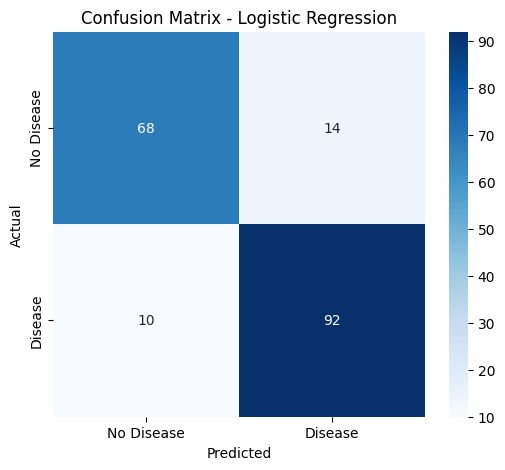

In [ ]:
# Plot Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Create Decision Tree model

dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
# Train the Decision Tree model

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Predict using Decision Tree

y_pred_dt = dt_model.predict(X_test)

# Display predictions

print(y_pred_dt[:10])

[1 1 0 1 1 0 0 1 0 1]


In [ ]:
# Calculate evaluation metrics

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")

Accuracy : 0.8261
Precision: 0.8431
Recall   : 0.8431
F1 Score : 0.8431


In [ ]:
# Display classification report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        82
           1       0.84      0.84      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



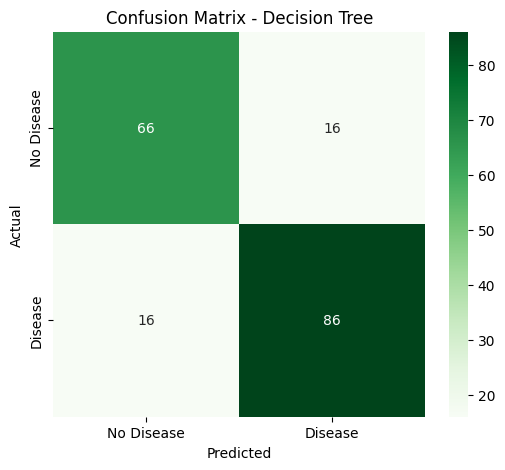

In [ ]:
# Plot Confusion Matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, accuracy_dt],
    "Precision": [precision, precision_dt],
    "Recall": [recall, recall_dt],
    "F1 Score": [f1, f1_dt]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.869565,0.867925,0.901961,0.884615
1,Decision Tree,0.826087,0.843137,0.843137,0.843137


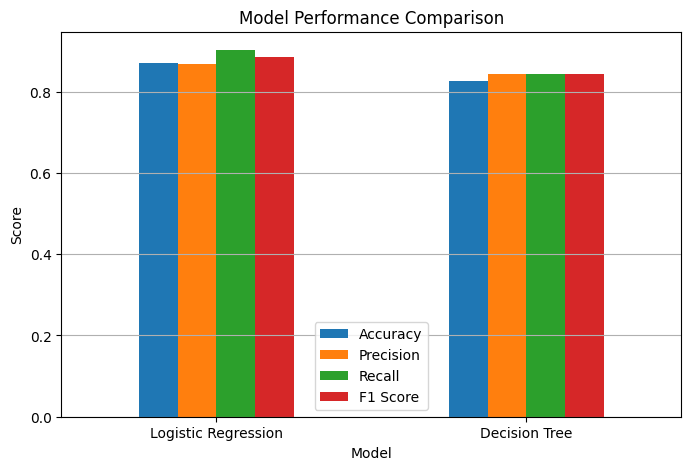

In [ ]:
# Visualize model comparison

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [ ]:
# Predict probabilities for ROC Curve

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Calculate ROC Curve and AUC Score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", round(auc_score, 4))

AUC Score: 0.9346


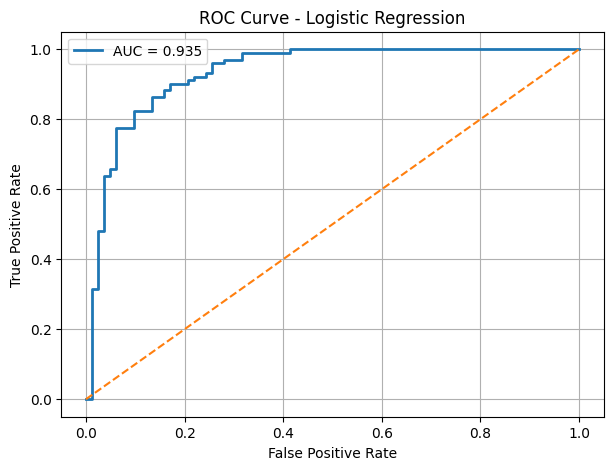

In [ ]:
# Plot ROC Curve

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", linewidth=2)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Create feature importance DataFrame

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,id,0.417781
8,ca,0.157241
1,age,0.085016
3,chol,0.065391
21,thal_reversable defect,0.054171
7,oldpeak,0.045871
2,trestbps,0.033964
20,thal_normal,0.027018
6,exang,0.025519
13,cp_atypical angina,0.018911


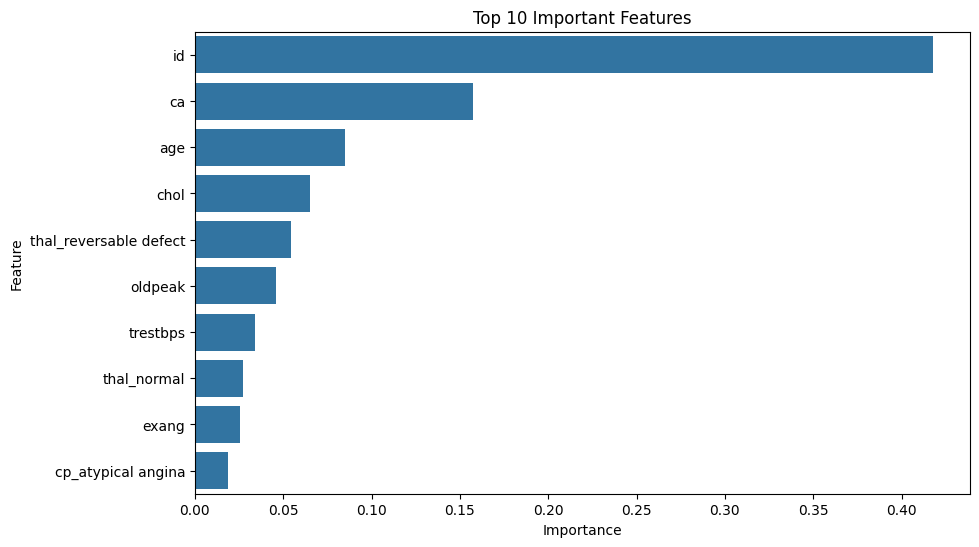

In [ ]:
# Plot Top 10 Important Features

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
# Save trained model

joblib.dump(log_model, "heart_disease_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
# Load saved model

loaded_model = joblib.load("heart_disease_model.pkl")

loaded_scaler = joblib.load("scaler.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
# Predict on test samples

sample = X_test.iloc[:5]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

print("Predictions:", prediction)

Predictions: [0 1 1 1 1]


## Observations

- The dataset was successfully cleaned and preprocessed.
- Missing values were handled using median and mode imputation.
- Categorical features were converted using One-Hot Encoding.
- Logistic Regression achieved higher performance than the Decision Tree model.
- Logistic Regression obtained an accuracy of approximately 86.96%, making it the best-performing model.
- The ROC Curve demonstrated good classification capability.
- The trained model was successfully saved and reloaded using Joblib for future predictions.

## Conclusion

A Machine Learning model was developed to predict the likelihood of heart disease using patient health data. Data preprocessing, feature scaling, model training, and evaluation were successfully completed. Logistic Regression outperformed Decision Tree based on evaluation metrics and was selected as the final model. The model was saved using Joblib, enabling it to be reused for future predictions. This project demonstrates a complete end-to-end Machine Learning pipeline for a real-world healthcare classification problem.